In [58]:
import functools
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt

from fintorch.utils.args import DefaultArgumentParser
from fintorch.utils.plot import *
from fintorch.utils.preprocess import *

In [2]:
args = DefaultArgumentParser.parse(args=[])

Output()

Output()

Output()

In [127]:
dc = args.online_exchange.future.data.get_data_collection(symbols=args.symbols, time_frames=args.time_frames)

sdf = dc.get_candles_df(symbol=args.symbol, time_frame=args.time_frame).copy()
sdf.insert(0, "datetime", [datetime.fromtimestamp(ts) for ts in sdf.index])
sdf["clean"] = sdf.close.rolling(window=5, center=True).mean()
sdf["roc"] = sdf.clean / sdf.clean.shift(1) - 1
sdf = sdf.dropna()

sdf

,datetime,open,high,low,close,volume,trade,clean,roc
timestamp,,,,,,,,,
1569715200,2019-09-29 03:30:00,8199.00,8226.35,7888.98,8041.96,35966.056,78128.0,8197.940,0.005639
1569801600,2019-09-30 03:30:00,8042.08,8331.89,7709.01,8285.84,54412.520,107329.0,8233.064,0.004284
1569888000,2019-10-01 03:30:00,8285.31,8499.00,8171.00,8290.00,39212.804,92166.0,8238.042,0.000605
1569974400,2019-10-02 03:30:00,8290.00,8365.92,8149.35,8352.14,30329.179,71452.0,8255.762,0.002151
1570060800,2019-10-03 03:30:00,8353.40,8386.00,8020.00,8220.27,33430.230,82221.0,8223.022,-0.003966
...,...,...,...,...,...,...,...,...,...
1714262400,2024-04-28 03:30:00,63420.90,64350.00,62700.00,63088.30,126056.151,2107056.0,62950.340,-0.012015
1714348800,2024-04-29 03:30:00,63088.40,64200.00,61726.20,63842.40,228411.163,3576356.0,61862.100,-0.017287
1714435200,2024-04-30 03:30:00,63842.40,64700.00,59150.00,60651.20,408747.703,5955376.0,60985.240,-0.014174


In [128]:
def similarity(roc, roc_val):
    return np.sum(roc.to_numpy() * roc_val.to_numpy())

In [150]:
SIMILARITY_CHECK_LENGTH = 30
START_INDEX = 200

for index in range(START_INDEX, len(sdf)): 
    df = sdf.iloc[:index]
    bdf = df.iloc[:-SIMILARITY_CHECK_LENGTH].copy()
    fdf = df.iloc[-SIMILARITY_CHECK_LENGTH:].copy()

    func = functools.partial(similarity, roc_val=fdf.roc)
    bdf["score"] = bdf.roc.rolling(window=len(roc_val)).apply(func=func)
    df["score"] = bdf.score
    # bdf = bdf.dropna()
    
    break

np.isnan(df.score).sum()

/tmp/ipykernel_1810548/2630392549.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["score"] = bdf.score


59

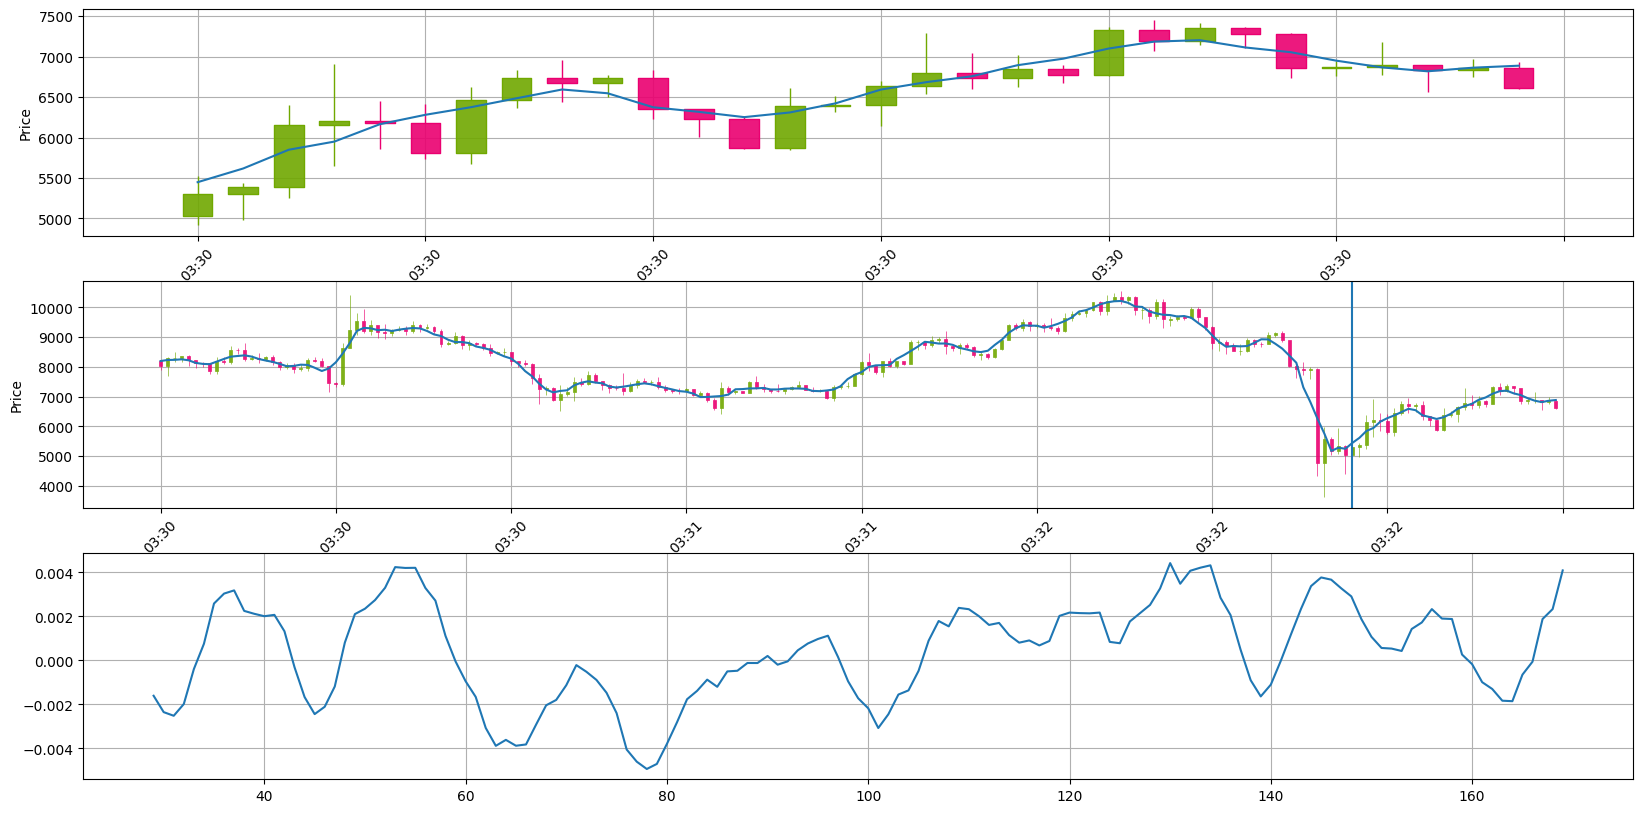

In [149]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(20, 10))

df = df.reset_index(drop=True)
bdf = bdf.reset_index(drop=True)
fdf = fdf.reset_index(drop=True)

draw_candlestick_plot(ax=axs[0], df=fdf)
axs[0].plot(fdf.clean)
axs[0].grid()

draw_candlestick_plot(ax=axs[1], df=df)
axs[1].plot(df.clean)
axs[1].axvline(len(bdf))
axs[1].grid()

axs[2].plot(df.score)
axs[2].grid()

In [126]:
transform: x, y -> cv: tss -> dataloader(tss): x, y -> model(x): y_hat -> y - y_hat -> loss -> model optimization -> model selection -> prediction 

SyntaxError: invalid syntax (1277647910.py, line 1)